# 03 — Priority bands, explanations and the inference artifact (Phase 4)

Reads saved outputs and the versioned artifact; fits nothing and does not re-score the test segment.
Built by `scripts/build_phase4.py` (`freeze-bands` → `test-bands` → `explain`).

**Primary outputs** for a lead are its **priority band** and its **ranking score / historical percentile**. The
calibrated probability is secondary and carries a drift warning.

In [1]:
import json, sys, warnings
from pathlib import Path

import pandas as pd
from IPython.display import Image, display

warnings.filterwarnings("ignore")
ROOT = Path.cwd().parent
sys.path.insert(0, str(ROOT))
from src import app_logic as app

REPORTS = ROOT / "reports"
rule = json.loads((REPORTS / "priority_rule.json").read_text())
{k: rule[k] for k in ("status", "rule", "ranking_score", "reference", "cutoffs", "tie_rule", "batch_mode")}

{'status': 'frozen before any band-level test results were computed',
 'rule': 'High = top 20% of ranking scores; Medium = next 30%; Low = remaining 50%',
 'ranking_score': 'log-odds (decision function) of the uncalibrated logistic regression',
 'reference': 'ranking scores of the validation period (Apr - May 2009), 4977 leads',
 'cutoffs': {'high_min': -2.5049519755460907,
  'medium_min': -2.721572274750752},
 'tie_rule': 'score >= cutoff goes to the higher band',
 'batch_mode': "the same 20/30/50 rule applied to the batch's own score distribution"}

## 1. Band performance on validation (reference period, Apr – May 2009)

In [2]:
pd.read_csv(REPORTS / 'bands_validation.csv').round(3)

,band,n_leads,share_of_leads,conversions,conversion_rate,share_of_conversions,lift,contacts_per_conversion,segment
0,High,996,0.2,209,0.210,0.329,1.645,4.766,validation (reference)
1,Medium,1493,0.3,211,0.141,0.332,1.108,7.076,validation (reference)
2,Low,2488,0.5,215,0.086,0.339,0.677,11.572,validation (reference)


## 2. Secondary operational characterisation on test (May 2009 – Nov 2010)
The frozen cutoffs were applied once to the saved Phase 3 test scores. These results did not and may not change the
cutoffs or the model. Two views: the fixed historical cutoffs, and the same 20/30/50 rule applied relative to the
test batch.

In [3]:
pd.read_csv(REPORTS / 'bands_test_secondary.csv').round(3)

,band,n_leads,share_of_leads,conversions,conversion_rate,share_of_conversions,lift,contacts_per_conversion,segment
0,High,2594,0.315,1208,0.466,0.476,1.511,2.147,test (secondary): reference cutoffs
1,Medium,1986,0.241,527,0.265,0.207,0.861,3.769,test (secondary): reference cutoffs
2,Low,3659,0.444,805,0.220,0.317,0.714,4.545,test (secondary): reference cutoffs
3,High,1648,0.200,896,0.544,0.353,1.764,1.839,test (secondary): batch-relative 20/30/50
4,Medium,2472,0.300,727,0.294,0.286,0.954,3.400,test (secondary): batch-relative 20/30/50
5,Low,4119,0.500,917,0.223,0.361,0.722,4.492,test (secondary): batch-relative 20/30/50


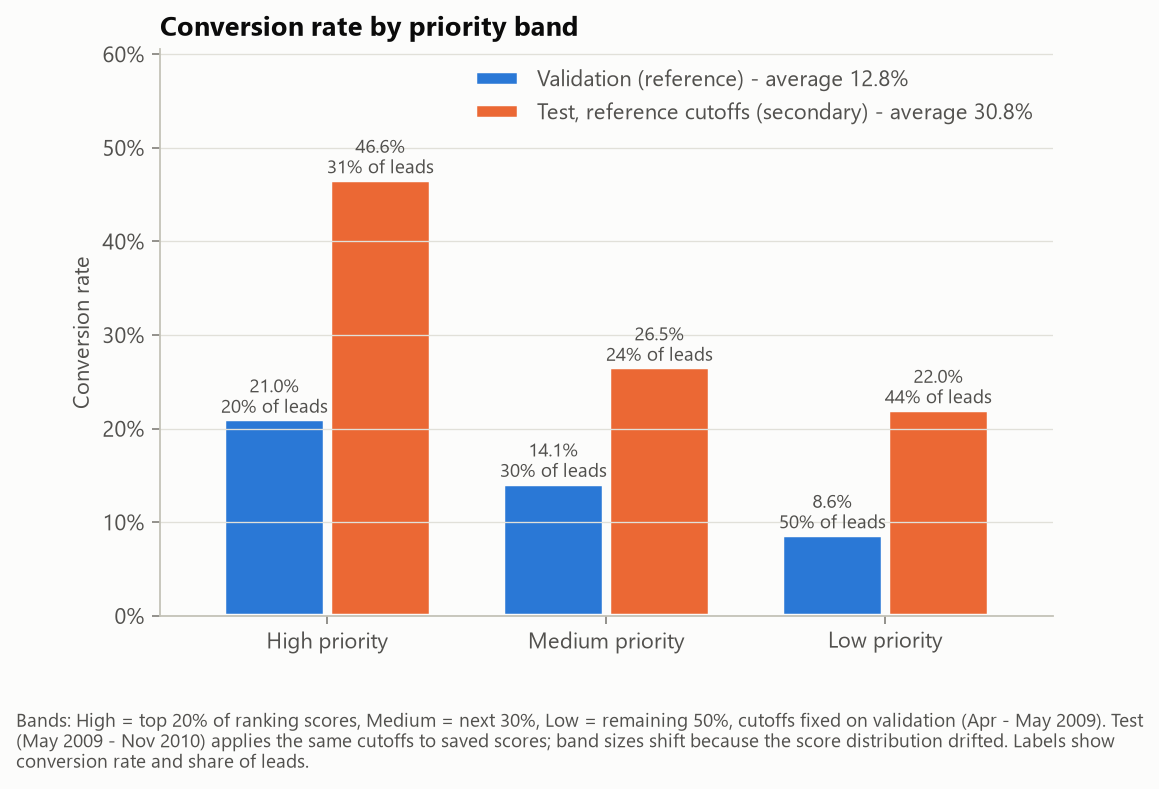

In [4]:
display(Image(REPORTS / 'figures' / 'priority_bands.png'))

## 3. SHAP explanations of the ranking model
Background: 1,000 development-period leads. Explained: validation leads. Values are contributions to the
log-odds ranking score, summed back to business fields. They describe what the model associates with a higher or
lower score, not causes of conversion, and they say nothing about the calibrated probability.

In [5]:
json.loads((REPORTS / 'shap_summary.json').read_text())

{'explains': 'log-odds ranking score of the frozen logistic regression (not the calibrated probability)',
 'background': '1000 development-period rows, seed 7',
 'explained_rows': 'validation period, 4977 leads',
 'base_value': -2.96640354395211,
 'additivity_max_abs_error': 8.881784197001252e-16,
 'interpretation': "Contributions are model associations: how much each field pushed this model's score up or down relative to an average development-period lead. They are not causal effects.",
 'local_examples': {'High': {'row': 30846,
   'selection_rule': 'validation lead whose ranking score is closest to the median of the High band',
   'priority': 'High',
   'ranking_score': -2.399314650223558,
   'historical_percentile': 90.014064697609},
  'Low': {'row': 31401,
   'selection_rule': 'validation lead whose ranking score is closest to the median of the Low band',
   'priority': 'Low',
   'ranking_score': -2.964162704118198,
   'historical_percentile': 24.994976893711073}}}

In [6]:
pd.read_csv(REPORTS / 'shap_global_importance.csv').round(3)

,feature,mean_abs_contribution,mean_contribution,field
0,contact,0.259,0.226,Contact channel
1,job,0.090,0.035,Job type
2,poutcome,0.085,-0.040,Earlier campaign outcome
3,day_of_week,0.084,-0.007,Call weekday
4,default,0.060,0.018,Credit in default
5,previous,0.055,-0.050,Contacts in earlier campaigns
6,prior_contacts_current_campaign,0.046,0.025,Earlier calls in this campaign
7,education,0.045,0.005,Education
8,marital,0.043,0.006,Marital status
9,age,0.040,0.005,Age


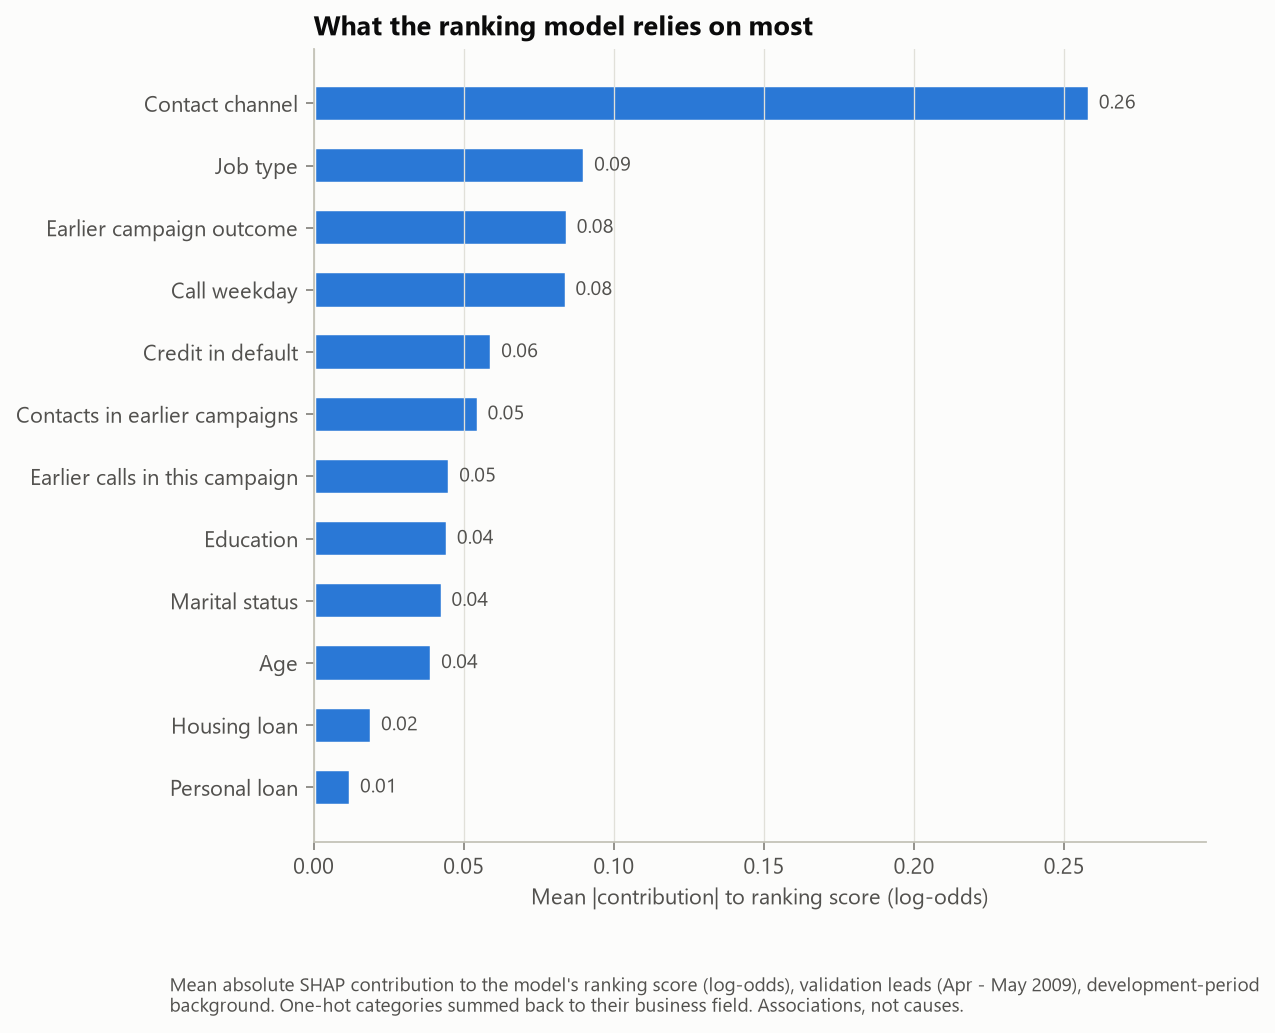

In [7]:
display(Image(REPORTS / 'figures' / 'shap_global_importance.png'))

In [8]:
pd.read_csv(REPORTS / 'shap_local_example_high.csv')[['description', 'contribution', 'sentence']].round(3)

,description,contribution,sentence
0,Contact channel: cellular,0.259,Contact channel: cellular pushed the model sco...
1,Job type: management,0.144,Job type: management pushed the model score hi...
2,Earlier calls in this campaign: 0,0.057,Earlier calls in this campaign: 0 pushed the m...
3,Credit in default: no,0.047,Credit in default: no pushed the model score h...
4,Age: 32,0.042,Age: 32 pushed the model score higher (+0.04 o...
5,Call weekday: tue,-0.041,Call weekday: tue pushed the model score lower...
6,Education: university.degree,0.028,Education: university.degree pushed the model ...
7,Marital status: divorced,0.028,Marital status: divorced pushed the model scor...
8,Housing loan: yes,-0.012,Housing loan: yes pushed the model score lower...
9,Personal loan: no,0.009,Personal loan: no pushed the model score highe...


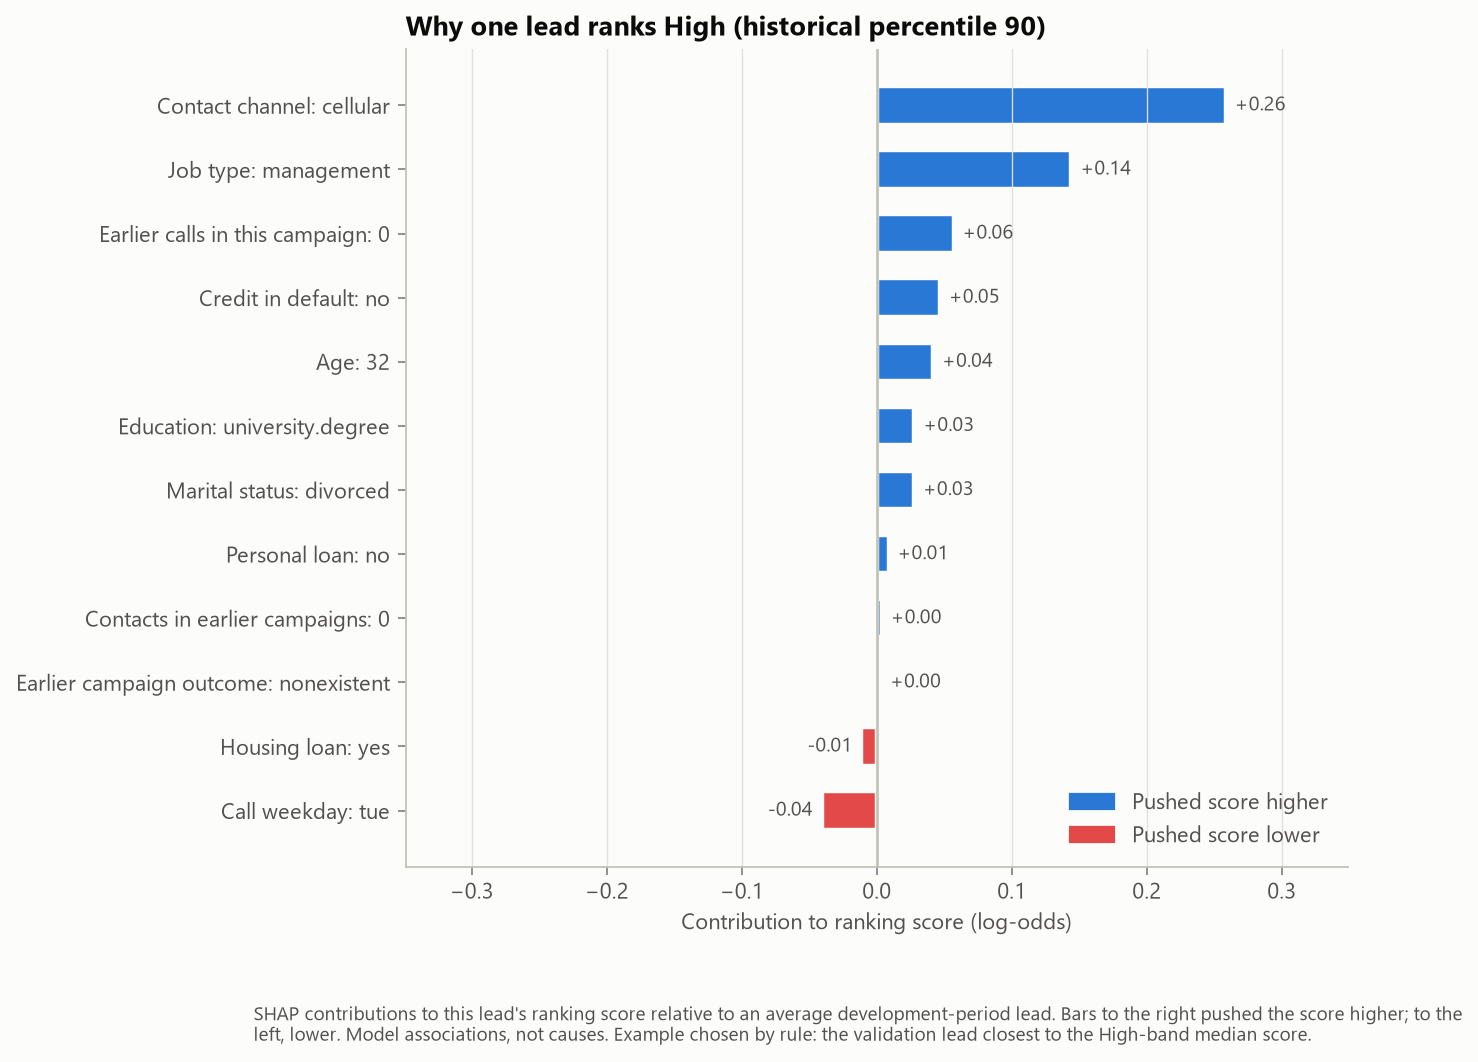

In [9]:
display(Image(REPORTS / 'figures' / 'shap_local_example_high.png'))

In [10]:
pd.read_csv(REPORTS / 'shap_local_example_low.csv')[['description', 'contribution', 'sentence']].round(3)

,description,contribution,sentence
0,Contacts in earlier campaigns: 2,-0.321,Contacts in earlier campaigns: 2 pushed the mo...
1,Contact channel: cellular,0.259,Contact channel: cellular pushed the model sco...
2,Earlier campaign outcome: failure,-0.224,Earlier campaign outcome: failure pushed the m...
3,Call weekday: wed,0.100,Call weekday: wed pushed the model score highe...
4,Marital status: single,0.070,Marital status: single pushed the model score ...
5,Credit in default: no,0.047,Credit in default: no pushed the model score h...
6,Education: professional.course,-0.030,Education: professional.course pushed the mode...
7,Job type: blue-collar,0.030,Job type: blue-collar pushed the model score h...
8,Earlier calls in this campaign: 1,0.024,Earlier calls in this campaign: 1 pushed the m...
9,Housing loan: no,0.023,Housing loan: no pushed the model score higher...


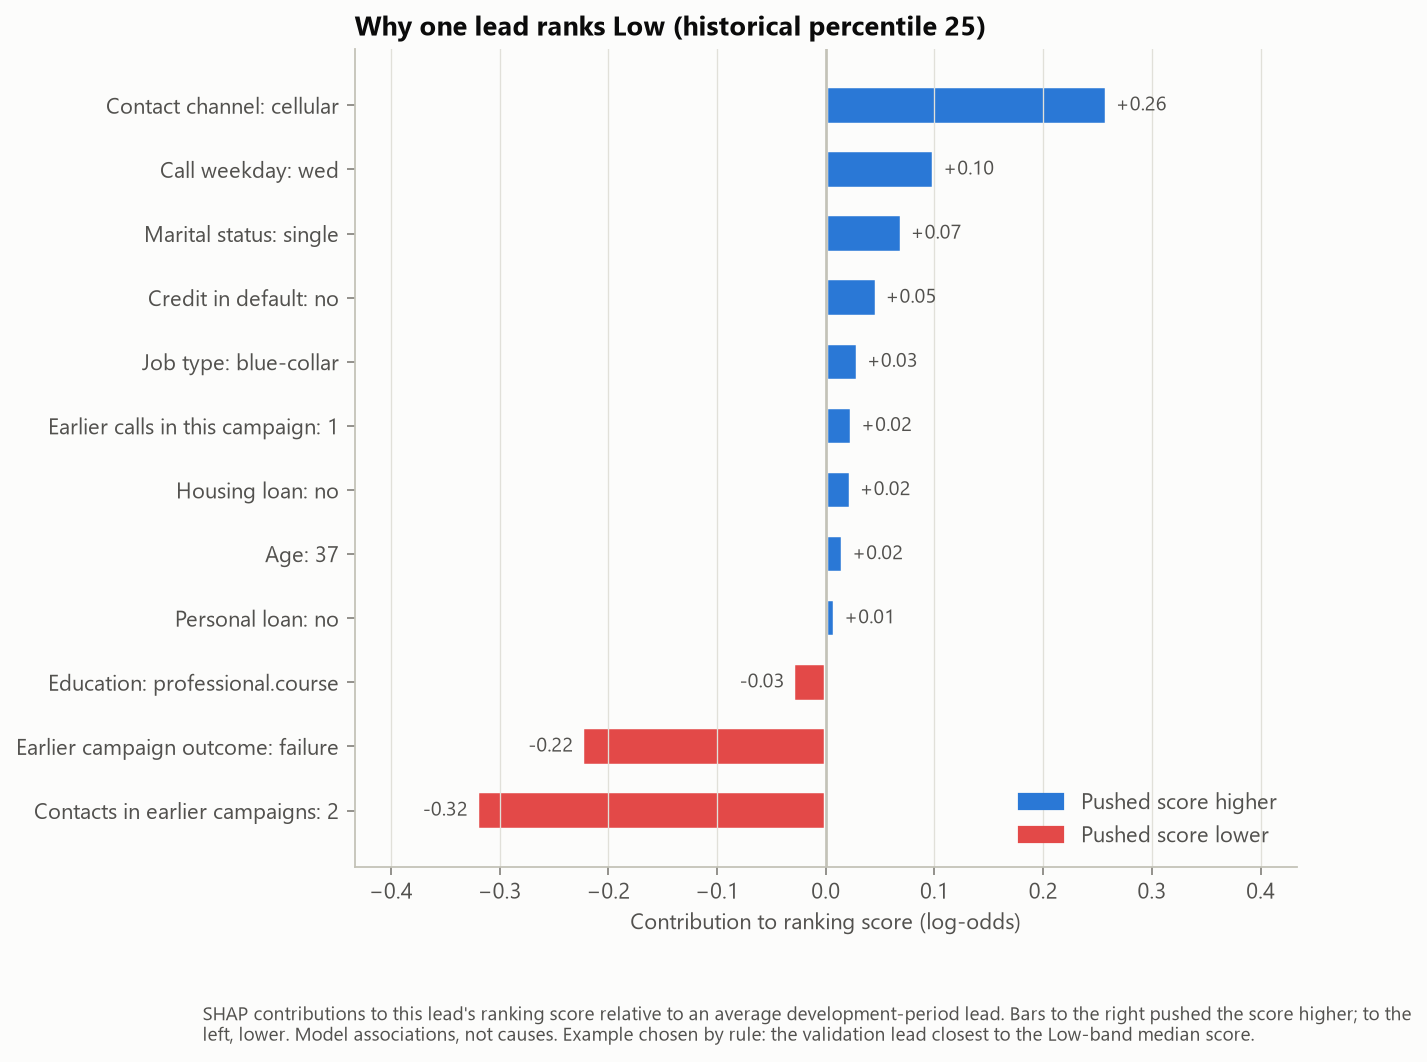

In [11]:
display(Image(REPORTS / 'figures' / 'shap_local_example_low.png'))

## 4. Using the committed deployment artifact
The app's minimal artifact (`artifacts/models/lead-scorer-1.0.0-deploy.joblib`) reproduces the full Phase 4
artifact exactly (see `tests/test_app.py`). Scoring the first eight example leads as one batch:

In [12]:
scorer = app.load_scorer()
leads = app.normalise_upload(pd.read_csv(app.EXAMPLE_CSV)).head(8)
valid, _ = app.split_valid(scorer, leads)
app.score_batch_table(scorer, valid)

,input_row,batch_rank,batch_priority,batch_percentile,historical_reference_priority,historical_percentile,age,job,marital_status,education,...,housing_loan,personal_loan,contact_channel,call_weekday,earlier_calls_this_campaign,earlier_campaign_contacts,previous_campaign_outcome,ranking_score,historical_calibrated_estimate,outside_training_range
0,5,1,High,100.0,High,83.1,32,blue-collar,married,basic.9y,...,yes,yes,cellular,fri,1,0,nonexistent,-2.4752,0.1600,False
1,8,2,High,87.5,Medium,64.3,32,technician,single,university.degree,...,no,no,cellular,tue,3,0,nonexistent,-2.6204,0.1369,False
2,7,3,Medium,75.0,Medium,55.2,44,technician,divorced,professional.course,...,no,no,cellular,tue,0,0,nonexistent,-2.6842,0.1277,False
3,2,4,Medium,62.5,Low,35.2,28,blue-collar,single,high.school,...,no,yes,cellular,thu,0,1,failure,-2.8455,0.1067,False
4,4,5,Low,50.0,Low,18.0,49,housemaid,married,basic.4y,...,no,no,cellular,fri,0,0,nonexistent,-3.0494,0.0846,False
5,1,6,Low,37.5,Low,12.2,44,admin.,married,unknown,...,no,no,cellular,wed,3,1,failure,-3.1279,0.0773,False
6,3,7,Low,25.0,Low,9.8,28,technician,single,professional.course,...,yes,no,cellular,thu,0,2,failure,-3.1672,0.0738,False
7,6,8,Low,12.5,Low,5.1,44,technician,married,unknown,...,yes,no,cellular,mon,0,1,failure,-3.2901,0.0639,False


In [13]:
print(scorer.metadata['calibration_warning'])

Secondary output. The probability calibration was fitted on April-May 2009 (12.8% conversion) and, on the later test period (30.8% conversion), predicted 14.7% on average. Calibration drifts when the overall conversion rate changes; it needs recent outcome data before these probabilities can be relied on. Use the priority band and ranking percentile for decisions.


## Limitations
- Bands are rank-based: when the score distribution shifts, the share of leads in each historical band shifts too
  (on test, 31% of leads fell in High). Batch-relative mode keeps 20/30/50 within each batch.
- SHAP explains this frozen model's associations as learned from 2008–early 2009. The weekday pattern reversed in
  later periods, and the single linear age term scores the small over-60 group lower even though it converted at
  high rates. Both are part of why the model's lift is moderate.
- Global importance is measured relative to the development-period background; fields whose mix changed a lot (e.g.
  contact channel, 51% cellular in development vs 94% in validation) look more important partly for that reason.
- The probability is secondary and drifts; it needs recent outcomes to be recalibrated.